In [1]:

import pandas as pd
import matplotlib.pyplot as plt
from openpyxl import load_workbook
from openpyxl.styles import Font

In [2]:
import pandas as pd

df = pd.read_csv("sales_data.csv")

df.head()

,date,Sales
0,2020-01-01,104.967142
1,2020-02-01,126.474500
2,2020-03-01,155.492441
3,2020-04-01,173.801727
4,2020-05-01,152.388308


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36 entries, 0 to 35
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   date    36 non-null     object 
 1   Sales   36 non-null     float64
dtypes: float64(1), object(1)
memory usage: 708.0+ bytes


In [11]:
print(df.shape)

(36, 2)


In [15]:
total_sales = df['Sales'].sum()

print("Total Sales =", total_sales)

Total Sales = 5341.366578051868


In [13]:
print(df.columns)

Index(['date', 'Sales'], dtype='object')


In [5]:
df['date'] = pd.to_datetime(df['date'])

df.head()

,date,Sales
0,2020-01-01,104.967142
1,2020-02-01,126.474500
2,2020-03-01,155.492441
3,2020-04-01,173.801727
4,2020-05-01,152.388308


In [6]:
df['Month'] = df['date'].dt.month

df.head()

,date,Sales,Month
0,2020-01-01,104.967142,1
1,2020-02-01,126.474500,2
2,2020-03-01,155.492441,3
3,2020-04-01,173.801727,4
4,2020-05-01,152.388308,5


In [7]:
total_sales = df['Sales'].sum()

print("Total Sales =", total_sales)

Total Sales = 5341.366578051868


In [8]:
average_sales = df['Sales'].mean()

print("Average Sales =", average_sales)

Average Sales = 148.3712938347741


In [9]:
max_sales = df['Sales'].max()

print("Maximum Sales =", max_sales)

Maximum Sales = 230.89983732631387


In [10]:
min_sales = df['Sales'].min()

print("Minimum Sales =", min_sales)

Minimum Sales = 74.86112880857142


In [11]:
monthly_sales = df.groupby('Month')['Sales'].sum()

print(monthly_sales)

Month
1     404.800080
2     467.022352
3     527.621582
4     591.935832
5     548.570436
6     518.598452
7     454.980536
8     399.931235
9     351.351532
10    322.590728
11    362.934172
12    391.029641
Name: Sales, dtype: float64


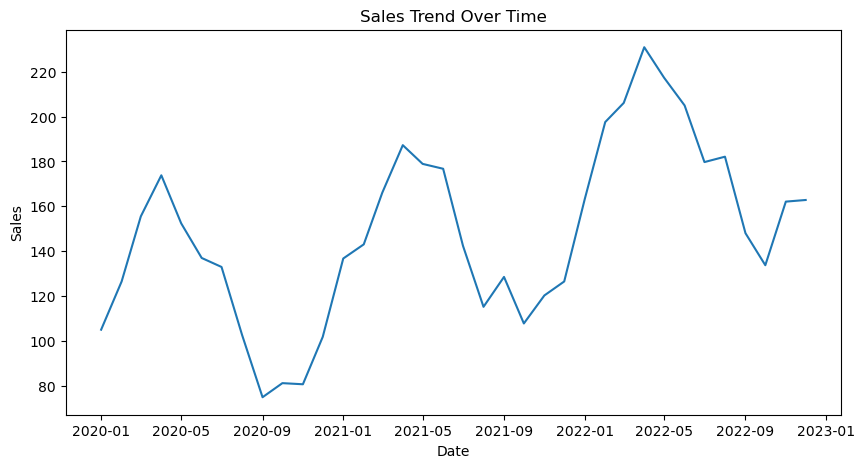

In [12]:
plt.figure(figsize=(10,5))

plt.plot(
    df['date'],
    df['Sales']
)

plt.title("Sales Trend Over Time")

plt.xlabel("Date")

plt.ylabel("Sales")

plt.show()

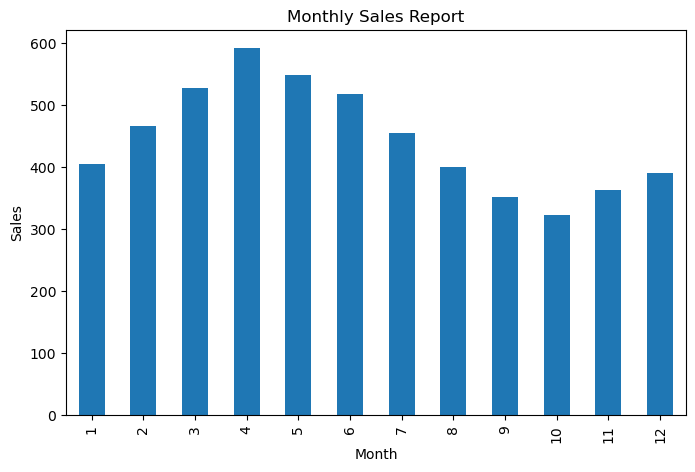

In [13]:
monthly_sales.plot(
    kind='bar',
    figsize=(8,5)
)

plt.title("Monthly Sales Report")

plt.xlabel("Month")

plt.ylabel("Sales")

plt.show()

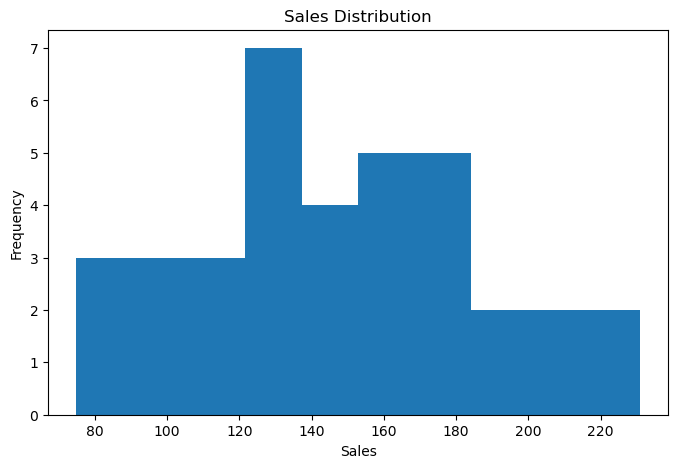

In [14]:
plt.figure(figsize=(8,5))

plt.hist(df['Sales'])

plt.title("Sales Distribution")

plt.xlabel("Sales")

plt.ylabel("Frequency")

plt.show()

In [15]:
with pd.ExcelWriter(
    "generated_report.xlsx",
    engine='openpyxl'
) as writer:

    df.to_excel(
        writer,
        sheet_name='Sales Data',
        index=False
    )

    monthly_sales.to_excel(
        writer,
        sheet_name='Monthly Sales'
    )

In [17]:
workbook = load_workbook("generated_report.xlsx")

sheet = workbook['Sales Data']

for cell in sheet[1]:
    cell.font = Font(bold=True)

workbook.save("generated_report.xlsx")

print("Excel report generated successfully!")

Excel report generated successfully!


In [18]:
print("Business Insights:")

print("- Sales show monthly fluctuations.")

print("- Overall sales trend increased over time.")

print("- Some months generated significantly higher sales.")

print("- Automated reporting successfully generated.")

Business Insights:
- Sales show monthly fluctuations.
- Overall sales trend increased over time.
- Some months generated significantly higher sales.
- Automated reporting successfully generated.
